In [21]:
import pandas as pd
import re
from datetime import datetime

# 1. 데이터 불러오기
try:
    df = pd.read_csv('data_market.csv', encoding='cp949')
except UnicodeDecodeError:
    try:
        df = pd.read_csv('data_market.csv', encoding='utf-8-sig')
    except UnicodeDecodeError:
        df = pd.read_csv('data_market.csv', encoding='utf-8')

# 2. 날짜 추출 함수
def extract_buy_date(text):
    if pd.isna(text): return None
    text = str(text)
    match1 = re.search(r'(\d{4})년\s*(\d{1,2})월\s*(\d{1,2})일', text)
    if match1: return f"{match1.group(1)}-{match1.group(2).zfill(2)}-{match1.group(3).zfill(2)}"
    match2 = re.search(r'(\d{4})[-./](\d{1,2})[-./](\d{1,2})', text)
    if match2: return f"{match2.group(1)}-{match2.group(2).zfill(2)}-{match2.group(3).zfill(2)}"
    return None

df['actual_buy_date'] = df['overall_sell'].apply(extract_buy_date)
df_clean = df.dropna(subset=['actual_buy_date', 'release_date_YYYY_MM']).copy()

# 3. 시간 변수 계산
df_clean['release_dt'] = pd.to_datetime(df_clean['release_date_YYYY_MM'], errors='coerce')
df_clean['buy_dt'] = pd.to_datetime(df_clean['actual_buy_date'], errors='coerce')
df_clean['device_age_months'] = (df_clean['buy_dt'].dt.year - df_clean['release_dt'].dt.year) * 12 + \
                                 (df_clean['buy_dt'].dt.month - df_clean['release_dt'].dt.month)
df_clean = df_clean[df_clean['device_age_months'] >= 0]

# 4. 사양 수치화
def convert_to_gb(value):
    if pd.isna(value): return None
    value = str(value).upper().replace(' ', '')
    num_match = re.search(r'(\d+\.?\d*)', value)
    if not num_match: return None
    num = float(num_match.group(1))
    return int(num * 1024) if 'TB' in value or 'T' in value else int(num)

df_clean['RAM_numeric'] = df_clean['RAM'].apply(convert_to_gb)
df_clean['SSD_numeric'] = df_clean['SSD'].apply(convert_to_gb)
df_clean['residual_ratio'] = (df_clean['unit_price'] / df_clean['release_price']) * 100

# [중요] 여기서 df_final을 정의합니다. 이후 모든 코드는 df_final을 사용합니다.
df_final = df_clean.copy()
print(f"✅ 1단계 완료: df_final 생성 성공 ({len(df_final)}건)")

✅ 1단계 완료: df_final 생성 성공 (1017건)


In [22]:
import numpy as np

# 1. 기준 정보 로드
file_path = '0.inspection_option.csv'
try:
    opt_df = pd.read_csv(file_path, encoding='utf-8-sig')
except UnicodeDecodeError:
    opt_df = pd.read_csv(file_path, encoding='cp949')

# 2. 매핑 테이블 생성 (이전 코드 유지)
mapping_master = {}
for item in opt_df['점검_항목명'].unique():
    sub_opts = opt_df[opt_df['점검_항목명'] == item].sort_values(by='감가_금액', ascending=False)
    opt_names = sub_opts['세부_옵션명'].tolist()
    n = len(opt_names)
    scores = {name: round(i / (n - 1), 2) for i, name in enumerate(opt_names)} if n > 1 else {opt_names[0]: 0.0}
    scores['해당없음'] = 0.0
    mapping_master[item] = scores

# 3. 데이터 적용 (df_final 사용)
inspection_cols = [
    '라이트닝케이블', '전원_케이블_노트북_', '전원_케이블_모바일_', '제품_박스_유무', 
    '제품_박스_유무_for_Acc_', '제품_박스_유무_iMac_', '작동_여부', '버튼_동작_iPad,_iPhone,_Galaxy_', 
    '힌지_고정_상태', '배터리_사이클', '변색', '생활_기스', '생활기스__for_Acc_', 
    '액정_상태', '찍힘_깨짐', '찍힘_깨짐__for_Acc_'
]
df_final[inspection_cols] = df_final[inspection_cols].fillna('해당없음')

for col in inspection_cols:
    item_name = col.replace('_', ' ').strip()
    if '찍힘' in item_name: item_name = '찍힘/깨짐'
    if '버튼' in item_name: item_name = '버튼 동작(iPad, iPhone, Galaxy)'
    
    if item_name in mapping_master:
        df_final[col] = df_final[col].map(mapping_master[item_name]).fillna(0)
    else:
        df_final[col] = 0

# 4. 상등품 기준선(Baseline A) 산출
# 상관계수 계산을 위해 price_gap(기준가-실제매입가)를 임시로 구합니다.
df_final['inspection_sum'] = df_final[inspection_cols].sum(axis=1)
s_class_df = df_final[df_final['inspection_sum'] == 0].copy()
trend_a = s_class_df.groupby(['title', 'device_age_months'])['residual_ratio'].mean().reset_index()
trend_a.columns = ['title', 'device_age_months', 'residual_ratio_baseline']

# 최종 데이터에 기준선 합치기
df_final = pd.merge(df_final, trend_a, on=['title', 'device_age_months'], how='left')
# 데이터가 없는 경우를 위해 평균값으로 보간
df_final['residual_ratio_baseline'] = df_final.groupby('title')['residual_ratio_baseline'].transform(lambda x: x.fillna(x.mean()))
# 가격 차이(Gap) 계산 (3단계 상관계수용)
df_final['price_gap'] = df_final['residual_ratio_baseline'] - df_final['residual_ratio']

print("✅ 2단계 완료: 상등품 기준선 및 price_gap 생성 완료")

✅ 2단계 완료: 상등품 기준선 및 price_gap 생성 완료


In [23]:
# 1. 상관계수 계산
results = []
for title in df_final['title'].unique():
    subset = df_final[df_final['title'] == title]
    if len(subset) < 5: continue
    valid_cols = [col for col in inspection_cols if subset[col].nunique() > 1]
    if valid_cols:
        corrs = subset[valid_cols].corrwith(subset['price_gap'])
        for col, val in corrs.items():
            results.append({'제품군': title, '점검항목': col, '상관계수': val})

corr_summary_df = pd.DataFrame(results)

# 2. [수정] 피벗 테이블 생성 및 가중치 정규화
pivot_corr = corr_summary_df.pivot(index='점검항목', columns='제품군', values='상관계수').fillna(0)
weight_df = pivot_corr.applymap(lambda x: x if x > 0 else 0)
normalized_weights = weight_df.div(weight_df.sum(axis=0), axis=1).fillna(0)

# 3. 가중치 적용 점수 계산 및 df_final 추가
def get_weighted_inspection_score(row):
    title = row['title']
    if title not in normalized_weights.columns: return 0
    score = 0
    for col in inspection_cols:
        item_weight = normalized_weights.loc[col, title] if col in normalized_weights.index else 0
        score += (row[col] * item_weight)
    return score

df_final['weighted_inspection_total'] = df_final.apply(get_weighted_inspection_score, axis=1)

def score_cpu(cpu_name):
    if pd.isna(cpu_name): return 0.1
    name = str(cpu_name).upper().replace(' ', '')
    
    # 1. 최상위 등급 (4.0 ~ 4.5) : M3/M4 라인업 및 Ultra/Max
    if any(x in name for x in ['M4ULTRA', 'M4MAX']): return 4.5
    if any(x in name for x in ['M3ULTRA', 'M3MAX']): return 4.3
    if any(x in name for x in ['M2ULTRA', 'M2MAX', 'M1ULTRA', 'M1MAX']): return 4.0
    
    # 2. 고성능 (3.0 ~ 3.9) : M시리즈 Pro 라인업
    if 'PRO' in name:
        if 'M4' in name: return 3.9
        if 'M3' in name: return 3.7
        if 'M2' in name: return 3.4
        if 'M1' in name: return 3.1
        return 3.0
    
    # 3. 기본 M / 최신 A (2.0 ~ 2.9) : 기본형 칩셋
    if any(x in name for x in ['M4', 'M3']): return 2.8
    if any(x in name for x in ['M2', 'M1']): return 2.5
    if any(x in name for x in ['A17PRO', 'A18']): return 2.4
    if any(x in name for x in ['A15', 'A16']): return 2.1
    
    # 4. 구형 A / 워치 S (1.0 ~ 1.9)
    if any(x in name for x in ['A12', 'A13', 'A14']): return 1.7
    if any(x in name for x in ['A8', 'A9', 'A10', 'A11']): return 1.3
    if 'S' in name and any(str(i) in name for i in range(5, 10)): return 1.1
    
    # 5. 인텔 및 기타 (0.1 ~ 0.9)
    if 'I9' in name: return 0.9
    if 'I7' in name: return 0.7
    if 'I5' in name: return 0.5
    if any(x in name for x in ['I3', 'COREM', 'PENTIUM']): return 0.3
    
    return 0.1 # 기본값

# CPU 스코어 적용 (수정 없음)
df_final['CPU_score'] = df_final['CPU'].apply(score_cpu)

print("✅ 4단계 완료: 가중치 점수 산출 및 CPU 스코어 적용 완료")

C:\Users\user\AppData\Local\Temp\ipykernel_7928\1124245515.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  weight_df = pivot_corr.applymap(lambda x: x if x > 0 else 0)


✅ 4단계 완료: 가중치 점수 산출 및 CPU 스코어 적용 완료


In [24]:
def preprocess_input(title_input, battery_val, scratch_txt, crack_txt):
    """입력된 텍스트와 수치를 모델용 데이터로 변환"""
    
    # 1. 제품명 매핑 (유연한 검색)
    title_input = title_input.lower()
    if 'iphone' in title_input: title = 'iPhone'
    elif 'macbook pro' in title_input: title = 'MacBook Pro'
    elif 'macbook air' in title_input: title = 'MacBook Air'
    elif 'ipad pro' in title_input: title = 'iPad Pro'
    elif 'ipad air' in title_input: title = 'iPad Air'
    else: title = 'iPhone' # 기본값
    
    # 2. 배터리 사이클 구간화
    try:
        b_val = float(battery_val)
        if b_val <= 50: battery_score = 0.0
        elif b_val <= 100: battery_score = 0.5
        else: battery_score = 1.0
    except: battery_score = 0.5 # 입력 오류 시 중간값
    
    # 3. 텍스트 감가 등급 변환
    mapping = {"없음": 0.0, "미세": 0.25, "약간": 0.6, "심함": 1.0}
    scratch_score = mapping.get(scratch_txt, 0.6)
    crack_score = mapping.get(crack_txt, 0.6)
    
    return title, battery_score, scratch_score, crack_score

def predict_my_device_price(title, release_price, age_months, ram, ssd, cpu, ins_results):
    """실제 학습된 모델(rf_model)을 사용하여 가격 예측"""
    
    # CPU 점수 변환 (이전에 정의한 score_cpu 함수 사용)
    c_s = score_cpu(cpu)
    
    # 가중치 점수 계산 (normalized_weights 사용)
    w_total = 0
    if title in normalized_weights.columns:
        for item, val in ins_results.items():
            # 가중치 테이블에 해당 항목이 있는지 확인
            w = normalized_weights.loc[item, title] if item in normalized_weights.index else 0
            w_total += (val * w)
    else:
        # 가중치 데이터가 없는 제품군일 경우 단순 평균
        w_total = sum(ins_results.values()) / len(ins_results)
            
    # 베이스라인 조회 (해당 제품의 평균 잔존율 베이스라인 사용)
    # trend_a_restored 데이터프레임에서 추출
    try:
        bl_val = trend_a_restored[trend_a_restored['title'] == title]['residual_ratio_baseline'].mean()
    except:
        bl_val = 50.0 # 데이터 없을 경우 기본값
    
    # 모델 입력용 데이터프레임 생성
    input_df = pd.DataFrame([{
        'device_age_months': age_months, 
        'RAM_numeric': ram, 
        'SSD_numeric': ssd,
        'CPU_score': c_s, 
        'weighted_inspection_total': w_total, 
        'residual_ratio_baseline': bl_val
    }])
    
    # 모델 예측 (rf_model이 이미 학습되어 있어야 함)
    pred_ratio = rf_model.predict(input_df)[0]
    
    return {
        '예측 잔존율': f"{pred_ratio:.2f}%",
        '예상 매입가': f"{int(round(release_price * (pred_ratio/100), -3)):,}원",
        '상태 페널티 점수': f"{w_total:.4f}"
    }

In [25]:
def run_advanced_calculator():
    print(f"\n{'='*50}")
    print(f"{' [ 🚀 고도화된 매입가 예측 시뮬레이터 ] '.center(46)}")
    print(f"{'='*50}\n")
    
    # 1. 기본 정보 입력
    raw_title = input("▣ 제품명 (예: iPhone 15 Pro, 맥북프로 M3): ")
    release_price = int(input("▣ 신품 출시가 (숫자만): "))
    age_months = int(input("▣ 사용 기간 (개월수): "))
    
    # 2. 사양 입력
    ram = int(input("▣ RAM 용량 (GB): "))
    ssd = int(input("▣ SSD 용량 (GB): "))
    cpu_input = input("▣ CPU 모델명 (예: M2, A17, i7): ")
    
    # 3. 세부 상태 입력
    print(f"\n{'-'*20} [ 세부 상태 입력 ] {'-'*20}")
    bat_input = input(" ▶ 배터리 사이클 횟수 (숫자): ")
    scr_input = input(" ▶ 생활 기스 상태 (없음/미세/약간/심함): ")
    cra_input = input(" ▶ 찍힘/깨짐 상태 (없음/미세/약간/심함): ")
    
    # 4. 전처리 실행 (이전에 정의한 preprocess_input 함수 호출)
    title, bat_s, scr_s, cra_s = preprocess_input(raw_title, bat_input, scr_input, cra_input)
    
    # 5. 예측용 데이터 구성
    ins_results = {
        '배터리_사이클': bat_s,
        '생활_기스': scr_s,
        '찍힘_깨짐': cra_s,
        '액정_상태': 0.0  # 액정 상태도 입력받으려면 위 입력칸을 추가하세요
    }
    
    # 6. 최종 예측 함수 호출 (이전에 학습된 rf_model 사용)
    result = predict_my_device_price(title, release_price, age_months, ram, ssd, cpu_input, ins_results)
    
    # 7. 결과 출력
    print(f"\n{'*' * 50}")
    print(f"  ■ 분석 대상: {raw_title} (그룹: {title})")
    print(f"  ■ 예상 잔존율: {result['예측 잔존율']}")
    print(f"  ■ 최종 매입가: {result['예상 매입가']}")
    print(f"  ■ 상태 페널티: {result['상태 페널티 점수']}")
    print(f"{'*' * 50}\n")

# --- 위 부분을 실행한 후, 아래 줄을 실행하세요 ---
run_advanced_calculator()


           [ 🚀 고도화된 매입가 예측 시뮬레이터 ]            



▣ 제품명 (예: iPhone 15 Pro, 맥북프로 M3):  iphone 15
▣ 신품 출시가 (숫자만):  5
▣ 사용 기간 (개월수):  5
▣ RAM 용량 (GB):  5
▣ SSD 용량 (GB):  5
▣ CPU 모델명 (예: M2, A17, i7):  5



-------------------- [ 세부 상태 입력 ] --------------------


 ▶ 배터리 사이클 횟수 (숫자):  5
 ▶ 생활 기스 상태 (없음/미세/약간/심함):  없음
 ▶ 찍힘/깨짐 상태 (없음/미세/약간/심함):  없음



**************************************************
  ■ 분석 대상: iphone 15 (그룹: iPhone)
  ■ 예상 잔존율: 64.83%
  ■ 최종 매입가: 0원
  ■ 상태 페널티: 0.0000
**************************************************



In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. 모델 학습
features = ['device_age_months', 'RAM_numeric', 'SSD_numeric', 'CPU_score', 'weighted_inspection_total', 'residual_ratio_baseline']
X = df_final[features].fillna(0)
y = df_final['residual_ratio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42)
rf_model.fit(X_train, y_train)

# 2. 예측 함수 정의 (추가된 부분: 기존 계산기에서 호출하는 함수)
def predict_my_device_price(title, release_price, age_months, ram, ssd, cpu, ins_results):
    # CPU 점수 변환
    c_s = score_cpu(cpu)
    
    # 가중치 점수 계산
    w_total = 0
    if title in normalized_weights.columns:
        for item, val in ins_results.items():
            w = normalized_weights.loc[item, title] if item in normalized_weights.index else 0
            w_total += (val * w)
            
    # 베이스라인 조회
    bl = trend_a[trend_a['title'] == title]['residual_ratio_baseline'].mean() # 간이 조회
    
    # 예측 데이터프레임
    input_df = pd.DataFrame([{
        'device_age_months': age_months, 'RAM_numeric': ram, 'SSD_numeric': ssd,
        'CPU_score': c_s, 'weighted_inspection_total': w_total, 'residual_ratio_baseline': bl
    }])
    
    pred_ratio = rf_model.predict(input_df)[0]
    return {
        '예측 잔존율': f"{pred_ratio:.2f}%",
        '예상 매입가': f"{int(round(release_price * (pred_ratio/100), -3)):,}원",
        '상태 페널티 점수': f"{w_total:.4f}"
    }

# 3. 계산기 실행
run_advanced_calculator()


           [ 🚀 고도화된 매입가 예측 시뮬레이터 ]            



▣ 제품명 (예: iPhone 15 Pro, 맥북프로 M3):  iphone
▣ 신품 출시가 (숫자만):  5
▣ 사용 기간 (개월수):  5
▣ RAM 용량 (GB):  5
▣ SSD 용량 (GB):  5
▣ CPU 모델명 (예: M2, A17, i7):  5



-------------------- [ 세부 상태 입력 ] --------------------


 ▶ 배터리 사이클 횟수 (숫자):  5
 ▶ 생활 기스 상태 (없음/미세/약간/심함):  없음
 ▶ 찍힘/깨짐 상태 (없음/미세/약간/심함):  없음



**************************************************
  ■ 분석 대상: iphone (그룹: iPhone)
  ■ 예상 잔존율: 59.17%
  ■ 최종 매입가: 0원
  ■ 상태 페널티: 0.0000
**************************************************



In [27]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np

# 1. 테스트 데이터셋에 대한 예측 수행
y_pred = rf_model.predict(X_test)

# 2. 성능 지표 계산
r2 = r2_score(y_test, y_pred)
mae_ratio = mean_absolute_error(y_test, y_pred) # 잔존율(%) 기준 오차
mape = mean_absolute_percentage_error(y_test, y_pred) * 100 # MAPE (%)

# 3. 실제 금액(원) 기준 MAE 계산
# 테스트 데이터의 인덱스를 사용하여 원본 출시가(release_price)를 가져옵니다.
test_release_prices = df_final.loc[X_test.index, 'release_price']
actual_prices = (y_test / 100) * test_release_prices
predicted_prices = (y_pred / 100) * test_release_prices
mae_won = np.mean(np.abs(actual_prices - predicted_prices))

print(f"[{'='*15} 모델 성능 평가 보고서 {'='*15}]")
print(f"1. R2 Score (결정계수) : {r2:.4f}")
print(f"   -> 1에 가까울수록 모델이 가격 변동을 잘 설명함 (현재 {r2*100:.1f}% 설명력)")
print("-" * 50)
print(f"2. MAE (잔존율 기준)   : {mae_ratio:.2f}%")
print(f"   -> 실제 잔존율과 평균적으로 {mae_ratio:.2f}%p 정도 차이가 남")
print("-" * 50)
print(f"3. MAE (금액 기준)     : {int(round(mae_won, -2)):,} 원")
print(f"   -> 실제 매입가와 평균적으로 약 {int(round(mae_won, -2)):,}원 정도 오차 발생")
print("-" * 50)
print(f"4. MAPE (백분율 오차)  : {mape:.2f}%")
print(f"   -> 전체 가격 대비 평균적인 오차 비중")
print(f"{'='*50}")

[=============== 모델 성능 평가 보고서 ===============]
1. R2 Score (결정계수) : 0.6138
   -> 1에 가까울수록 모델이 가격 변동을 잘 설명함 (현재 61.4% 설명력)
--------------------------------------------------
2. MAE (잔존율 기준)   : 7.22%
   -> 실제 잔존율과 평균적으로 7.22%p 정도 차이가 남
--------------------------------------------------
3. MAE (금액 기준)     : 134,400 원
   -> 실제 매입가와 평균적으로 약 134,400원 정도 오차 발생
--------------------------------------------------
4. MAPE (백분율 오차)  : 33.24%
   -> 전체 가격 대비 평균적인 오차 비중


In [28]:
#오차가 가장 큰 데이터 확인(top10)
# 예측값과 실제값 비교 테이블 생성
val_df = X_test.copy()
val_df['actual_ratio'] = y_test
val_df['pred_ratio'] = y_pred
val_df['actual_price'] = (y_test / 100) * df_final.loc[X_test.index, 'release_price']
val_df['pred_price'] = (y_pred / 100) * df_final.loc[X_test.index, 'release_price']
val_df['error_won'] = np.abs(val_df['actual_price'] - val_df['pred_price'])
val_df['title'] = df_final.loc[X_test.index, 'title']

# 오차가 큰 순서대로 보기 (상위 10개)
print("--- [분석] 오차(금액 기준)가 가장 큰 상위 10개 데이터 ---")
display_cols = ['title', 'device_age_months', 'actual_price', 'pred_price', 'error_won', 'actual_ratio', 'pred_ratio']
print(val_df[display_cols].sort_values(by='error_won', ascending=False).head(10))

--- [분석] 오차(금액 기준)가 가장 큰 상위 10개 데이터 ---
           title  device_age_months  actual_price    pred_price     error_won  \
655  MacBook Pro                 23  6.233333e+05  1.633469e+06  1.010135e+06   
963  MacBook Pro                 23  2.750000e+06  1.959159e+06  7.908412e+05   
662  MacBook Pro                 63  1.530000e+06  8.013152e+05  7.286848e+05   
657  MacBook Pro                 50  1.830000e+06  1.151284e+06  6.787164e+05   
893         iMac                 49  1.480000e+06  8.191073e+05  6.608927e+05   
482     Mac Mini                 61  7.200000e+05  1.964979e+05  5.235021e+05   
664  MacBook Pro                 64  1.500000e+06  9.845306e+05  5.154694e+05   
136  MacBook Pro                 19  7.000000e+05  1.213675e+06  5.136747e+05   
309  MacBook Pro                 34  1.080000e+06  1.570118e+06  4.901176e+05   
310  MacBook Pro                 34  1.100000e+06  1.570118e+06  4.701176e+05   

     actual_ratio  pred_ratio  
655     19.540230   51.205919  
963 

In [29]:
#이상치(잔존가치 10%미만 또는 100%이상)제거 및 하이퍼 파라미터 튜닝
# 1. 이상치 제거 (잔존율 10% 미만 혹은 100% 초과 데이터는 노이즈일 가능성 농후)
df_final_v2 = df_final[(df_final['residual_ratio'] >= 10) & (df_final['residual_ratio'] <= 100)].copy()

# 2. 피처와 타겟 재설정
X_v2 = df_final_v2[features].fillna(0)
y_v2 = df_final_v2['residual_ratio']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

# 3. 모델 하이퍼파라미터 강화 (일반화 성능 향상)
rf_model_v2 = RandomForestRegressor(
    n_estimators=500,        # 나무 개수를 늘려 안정성 확보
    max_depth=10,            # 너무 깊게 학습하지 않도록 제한
    min_samples_leaf=4,      # 한 잎에 최소 4개 데이터가 있어야 함 (이상치 영향 감소)
    random_state=42
)
rf_model_v2.fit(X_train_v2, y_train_v2)

print("✅ 재학습 완료: 이상치 제거 및 하이퍼파라미터 튜닝 적용됨")

✅ 재학습 완료: 이상치 제거 및 하이퍼파라미터 튜닝 적용됨


In [30]:
#개선지표 확인
# 새 모델로 예측
y_pred_v2 = rf_model_v2.predict(X_test_v2)

# 지표 계산
r2_v2 = r2_score(y_test_v2, y_pred_v2)
mae_ratio_v2 = mean_absolute_error(y_test_v2, y_pred_v2)
mape_v2 = mean_absolute_percentage_error(y_test_v2, y_pred_v2) * 100

# 금액 기준 MAE 계산
test_release_prices_v2 = df_final_v2.loc[X_test_v2.index, 'release_price']
mae_won_v2 = np.mean(np.abs((y_test_v2/100)*test_release_prices_v2 - (y_pred_v2/100)*test_release_prices_v2))

print(f"[{'='*15} 개선된 모델 성능 보고서 {'='*15}]")
print(f"1. R2 Score (결정계수) : {r2_v2:.4f} (이전: 0.6138)")
print(f"2. MAE (잔존율 기준)   : {mae_ratio_v2:.2f}% (이전: 7.22%)")
print(f"3. MAE (금액 기준)     : {int(round(mae_won_v2, -2)):,} 원 (이전: 134,400원)")
print(f"4. MAPE (백분율 오차)  : {mape_v2:.2f}% (이전: 33.24%)")
print(f"{'='*50}")

[=============== 개선된 모델 성능 보고서 ===============]
1. R2 Score (결정계수) : 0.6872 (이전: 0.6138)
2. MAE (잔존율 기준)   : 6.87% (이전: 7.22%)
3. MAE (금액 기준)     : 132,100 원 (이전: 134,400원)
4. MAPE (백분율 오차)  : 21.93% (이전: 33.24%)


In [31]:
from sklearn.linear_model import LinearRegression
import numpy as np

# [수정] RAM이나 SSD 정보가 없는 데이터는 0으로 채우거나 제거합니다.
# 여기서는 분석의 정확도를 위해 사양 정보가 있는 데이터만 사용하도록 필터링하겠습니다.
df_final_v2_clean = df_final_v2.dropna(subset=['RAM_numeric', 'SSD_numeric']).copy()

# 1. 사양 기여도 산출
spec_model = LinearRegression()
X_spec = df_final_v2_clean[['RAM_numeric', 'SSD_numeric']]
y_spec = df_final_v2_clean['residual_ratio']
spec_model.fit(X_spec, y_spec)

ram_coef = spec_model.coef_[0]
ssd_coef = spec_model.coef_[1]

print(f"📊 분석 결과 - RAM 1GB당: {ram_coef:.3f}%p, SSD 1GB당: {ssd_coef:.3f}%p 잔존율 영향 확인")

# 2. 사양 영향을 뺀 '순수 잔존율' 계산 (원본 v2에 적용)
# 결측치는 0으로 간주하여 계산합니다.
df_final_v2['pure_residual_ratio'] = (
    df_final_v2['residual_ratio'] 
    - (df_final_v2['RAM_numeric'].fillna(0) * ram_coef) 
    - (df_final_v2['SSD_numeric'].fillna(0) * ssd_coef)
)

# 3. 제품명/연식별 '순수 S급 베이스라인' 재산출
pure_trend_a = df_final_v2.groupby(['title', 'device_age_months'])['pure_residual_ratio'].mean().reset_index()
pure_trend_a.columns = ['title', 'device_age_months', 'pure_baseline_ratio']

# 4. 데이터 합치기 (v3 생성)
df_final_v3 = pd.merge(df_final_v2, pure_trend_a, on=['title', 'device_age_months'], how='left')

# 베이스라인 결측치 채우기 (전체 평균)
df_final_v3['pure_baseline_ratio'] = df_final_v3.groupby('title')['pure_baseline_ratio'].transform(lambda x: x.fillna(x.mean()))

print("✅ v3 데이터 준비 완료: ValueError 해결 및 pure_baseline_ratio 생성 성공")

📊 분석 결과 - RAM 1GB당: -0.032%p, SSD 1GB당: -0.001%p 잔존율 영향 확인
✅ v3 데이터 준비 완료: ValueError 해결 및 pure_baseline_ratio 생성 성공


In [32]:
# 1. 모델 학습 (v3 데이터 사용_기준선에 사양항목도 추가)
features = ['device_age_months', 'RAM_numeric', 'SSD_numeric', 'CPU_score', 'weighted_inspection_total', 'pure_baseline_ratio'] # 수정됨
X_v3 = df_final_v3[features].fillna(0)
y_v3 = df_final_v3['residual_ratio']

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(X_v3, y_v3, test_size=0.2, random_state=42)
rf_model_v3 = RandomForestRegressor(n_estimators=500, max_depth=10, min_samples_leaf=4, random_state=42)
rf_model_v3.fit(X_train_v3, y_train_v3)

# 2. 예측 함수 수정
def predict_my_device_price(title, release_price, age_months, ram, ssd, cpu, ins_results):
    c_s = score_cpu(cpu)
    w_total = 0
    if title in normalized_weights.columns:
        for item, val in ins_results.items():
            w = normalized_weights.loc[item, title] if item in normalized_weights.index else 0
            w_total += (val * w)
            
    # [수정] pure_baseline_ratio 사용
    try:
        bl = pure_trend_a[pure_trend_a['title'] == title]['pure_baseline_ratio'].mean()
    except:
        bl = 50.0 
    
    input_df = pd.DataFrame([{
        'device_age_months': age_months, 'RAM_numeric': ram, 'SSD_numeric': ssd,
        'CPU_score': c_s, 'weighted_inspection_total': w_total, 
        'pure_baseline_ratio': bl # 수정됨
    }])
    
    pred_ratio = rf_model_v3.predict(input_df)[0]
    return {
        '예측 잔존율': f"{pred_ratio:.2f}%",
        '예상 매입가': f"{int(round(release_price * (pred_ratio/100), -3)):,}원",
        '상태 페널티 점수': f"{w_total:.4f}"
    }

print("✅ 모델 재학습 및 계산기 업데이트 완료!")

✅ 모델 재학습 및 계산기 업데이트 완료!


In [33]:
#재학습 모델의 성능
y_pred_v3 = rf_model_v3.predict(X_test_v3)

r2_v3 = r2_score(y_test_v3, y_pred_v3)
mae_ratio_v3 = mean_absolute_error(y_test_v3, y_pred_v3)
mape_v3 = mean_absolute_percentage_error(y_test_v3, y_pred_v3) * 100

test_release_prices_v3 = df_final_v3.loc[X_test_v3.index, 'release_price']
mae_won_v3 = np.mean(np.abs((y_test_v3/100)*test_release_prices_v3 - (y_pred_v3/100)*test_release_prices_v3))

print(f"[{'='*15} 최종 고도화(v3) 모델 성능 보고서 {'='*15}]")
print(f"1. R2 Score (결정계수) : {r2_v3:.4f} (이전 v2: 0.6872)")
print(f"2. MAE (잔존율 기준)   : {mae_ratio_v3:.2f}% (이전 v2: 6.87%)")
print(f"3. MAE (금액 기준)     : {int(round(mae_won_v3, -2)):,} 원 (이전 v2: 132,100원)")
print(f"4. MAPE (백분율 오차)  : {mape_v3:.2f}% (이전 v2: 21.93%)")
print(f"{'='*50}")

[=============== 최종 고도화(v3) 모델 성능 보고서 ===============]
1. R2 Score (결정계수) : 0.7860 (이전 v2: 0.6872)
2. MAE (잔존율 기준)   : 5.48% (이전 v2: 6.87%)
3. MAE (금액 기준)     : 110,900 원 (이전 v2: 132,100원)
4. MAPE (백분율 오차)  : 17.24% (이전 v2: 21.93%)


In [34]:
# 함수 재정의 이후 계산기
run_advanced_calculator()


           [ 🚀 고도화된 매입가 예측 시뮬레이터 ]            



▣ 제품명 (예: iPhone 15 Pro, 맥북프로 M3):  iphone
▣ 신품 출시가 (숫자만):  1400000
▣ 사용 기간 (개월수):  22
▣ RAM 용량 (GB):  6
▣ SSD 용량 (GB):  128
▣ CPU 모델명 (예: M2, A17, i7):  a16



-------------------- [ 세부 상태 입력 ] --------------------


 ▶ 배터리 사이클 횟수 (숫자):  55
 ▶ 생활 기스 상태 (없음/미세/약간/심함):  없음
 ▶ 찍힘/깨짐 상태 (없음/미세/약간/심함):  없음



**************************************************
  ■ 분석 대상: iphone (그룹: iPhone)
  ■ 예상 잔존율: 41.37%
  ■ 최종 매입가: 579,000원
  ■ 상태 페널티: 0.1346
**************************************************



In [35]:
#시리즈명 재학습코드_v4
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. 등급 매핑 사전 정의
series_grade_map = {
    'promax': 4.5, 'ultra': 4.5, 'max': 4.0,
    'pro': 3.5, 'air': 2.5, 'mini': 2.0, 'plus': 2.0
}

def get_series_score(title):
    t = str(title).lower().replace(' ', '')
    for keyword, score in series_grade_map.items():
        if keyword in t:
            return score
    return 1.0  # 일반(Normal) 모델 기본점수

# 2. 데이터셋 업데이트
df_final_v3['Series_Score'] = df_final_v3['title'].apply(get_series_score)

# 3. 피처 리스트 업데이트 (Series_Score 추가)
features_v4 = [
    'device_age_months', 'RAM_numeric', 'SSD_numeric', 
    'CPU_score', 'weighted_inspection_total', 
    'pure_baseline_ratio', 'Series_Score' # 신규 추가
]

X_v4 = df_final_v3[features_v4].fillna(0)
y_v4 = df_final_v3['residual_ratio']

# 4. 모델 재학습
X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(X_v4, y_v4, test_size=0.2, random_state=42)
rf_model_v4 = RandomForestRegressor(n_estimators=500, max_depth=12, min_samples_leaf=3, random_state=42)
rf_model_v4.fit(X_train_v4, y_train_v4)

print("✅ 1단계 완료: Series_Score 반영 모델 재학습 성공")

✅ 1단계 완료: Series_Score 반영 모델 재학습 성공


In [36]:
#v4 및 사용성(구매일자)개선 계산기
from datetime import datetime

def run_final_v4_calculator():
    print(f"\n{'='*60}")
    print(f"{' [ 🏆 v4.0 날짜 기반 지능형 매입가 계산기 ] '.center(56)}")
    print(f"{'='*60}\n")
    
    # 1. 입력부
    raw_title = input("▣ 제품명 (예: iPhone 15 Pro, MacBook Air M2): ")
    release_price = int(input("▣ 신품 출시가 (숫자만): "))
    purchase_date_str = input("▣ 출시(또는 구매)년월 (예: 2024-05 또는 202405): ")
    
    # 2. 날짜 기반 개월수 계산 (2026-03 기준)
    try:
        p_date = purchase_date_str.replace('.', '-').replace('/', '-')
        if len(p_date) == 6: p_date = f"{p_date[:4]}-{p_date[4:]}"
        start_date = datetime.strptime(p_date, "%Y-%m")
        current_date = datetime(2026, 3, 1) # 현재 시점 고정
        age_months = (current_date.year - start_date.year) * 12 + (current_date.month - start_date.month)
        age_months = max(0, age_months)
    except:
        print("⚠️ 날짜 형식이 잘못되어 기본값 12개월로 설정합니다.")
        age_months = 12

    # 3. 사양 및 상태 입력
    ram = int(input("▣ RAM (GB): "))
    ssd = int(input("▣ SSD (GB): "))
    cpu_input = input("▣ CPU 모델명 (예: M3, A17, i7): ")
    
    print(f"\n{'-'*20} [ 기기 상태 점검 (0:없음, 1:미세, 2:약간, 3:심함) ] {'-'*20}")
    bat_val = input(" ▶ 배터리 사이클: ")
    scr_idx = input(" ▶ 생활 기스 정도 (0~3): ")
    cra_idx = input(" ▶ 찍힘/깨짐 정도 (0~3): ")
    
    state_map = {"0": "없음", "1": "미세", "2": "약간", "3": "심함"}
    scr_txt = state_map.get(scr_idx, "약간")
    cra_txt = state_map.get(cra_idx, "약간")

    # 4. 전처리 및 예측
    title_group, bat_s, scr_s, cra_s = preprocess_input(raw_title, bat_val, scr_txt, cra_txt)
    series_s = get_series_score(raw_title) # 등급 점수 추출
    cpu_s = score_cpu(cpu_input)
    
    # 베이스라인 조회
    try:
        bl = pure_trend_a[pure_trend_a['title'] == title_group]['pure_baseline_ratio'].mean()
    except: bl = 50.0

    # 검수 가중치 합산
    w_total = 0
    ins_results = {'배터리_사이클': bat_s, '생활_기스': scr_s, '찍힘_깨짐': cra_s, '액정_상태': 0.0}
    if title_group in normalized_weights.columns:
        for item, val in ins_results.items():
            w = normalized_weights.loc[item, title_group] if item in normalized_weights.index else 0
            w_total += (val * w)

    # 최종 예측
    input_df = pd.DataFrame([{
        'device_age_months': age_months, 'RAM_numeric': ram, 'SSD_numeric': ssd,
        'CPU_score': cpu_s, 'weighted_inspection_total': w_total, 
        'pure_baseline_ratio': bl, 'Series_Score': series_s
    }])
    
    pred_ratio = rf_model_v4.predict(input_df)[0]
    final_price = int(round(release_price * (pred_ratio/100), -3))

    # 5. 결과 출력
    print(f"\n{'*' * 60}")
    print(f" [ 분석 정보 ] {raw_title} | 등급점수: {series_s} | 경과: {age_months}개월")
    print(f" 💰 최종 예상 매입가 : {final_price:,} 원")
    print(f" 📊 예상 잔존율 : {pred_ratio:.2f}%")
    print(f"{'*' * 60}\n")

# 실행
run_final_v4_calculator()


              [ 🏆 v4.0 날짜 기반 지능형 매입가 계산기 ]              



▣ 제품명 (예: iPhone 15 Pro, MacBook Air M2):  iphone
▣ 신품 출시가 (숫자만):  15
▣ 출시(또는 구매)년월 (예: 2024-05 또는 202405):  2022-09
▣ RAM (GB):  6
▣ SSD (GB):  128
▣ CPU 모델명 (예: M3, A17, i7):  a16



-------------------- [ 기기 상태 점검 (0:없음, 1:미세, 2:약간, 3:심함) ] --------------------


 ▶ 배터리 사이클:  55
 ▶ 생활 기스 정도 (0~3):  0
 ▶ 찍힘/깨짐 정도 (0~3):  0



************************************************************
 [ 분석 정보 ] iphone | 등급점수: 1.0 | 경과: 42개월
 💰 최종 예상 매입가 : 0 원
 📊 예상 잔존율 : 41.45%
************************************************************



In [37]:
#v4 계산기 수정본
def run_ultimate_calculator_v42():
    print(f"\n{'='*65}")
    print(f"{' [ 중고 전자기기 매입가격 예측 계산기 ] '.center(61)}")
    print(f"{'='*65}\n")
    
    # 1. 기본 정보 입력
    raw_title = input("▣ 제품명 (예: iPhone 15 Pro, MacBook Air M2): ")
    release_price = int(input("▣ 신품 출시가 (예: 1550000): "))
    purchase_date_str = input("▣ 출시/구매년월 (예: 2023-10, 202401): ")
    
    # 2. 날짜 계산 (2026-03 기준)
    try:
        p_date = purchase_date_str.replace('.', '-').replace('/', '-')
        if len(p_date) == 6: p_date = f"{p_date[:4]}-{p_date[4:]}"
        start_date = datetime.strptime(p_date, "%Y-%m")
        current_date = datetime(2026, 3, 1)
        age_months = (current_date.year - start_date.year) * 12 + (current_date.month - start_date.month)
        age_months = max(0, age_months)
    except: age_months = 12

    # 3. 사양 입력
    print(f"\n{'-'*20} [ 핵심 사양 및 CPU ] {'-'*20}")
    ram = int(input(" ▶ RAM 용량 (숫자만, 예: 8, 16): "))
    ssd = int(input(" ▶ SSD 용량 (숫자만, 예: 256, 512): "))
    print(" 💡 CPU 예시: M3 Max, M2 Pro, A17 Pro, A16, i7, i5 등")
    cpu_input = input(" ▶ CPU 모델명 입력: ")
    
    # 4. 상태 입력 (가이드 강화)
    print(f"\n{'-'*15} [ 상태 점검 가이드 ] {'-'*15}")
    print(" ※ 입력 가능값: [없음(0), 미세(1), 약간(2), 심함(3)]")
    
    bat_raw = input(" ▶ 배터리 사이클 (실제 횟수 숫자 입력): ")
    scr_raw = input(" ▶ 생활 기스 정도 (예: 없음, 미세, 2): ")
    cra_raw = input(" ▶ 찍힘/깨짐 정도 (예: 없음, 심함, 0): ")
    
    # 점수화 변환 (이전 정의된 함수 사용)
    bat_s = get_battery_score(bat_raw)
    scr_s = get_status_score(scr_raw)
    cra_s = get_status_score(cra_raw)
    
    # 5. 모델 예측 로직 (v4 모델 사용)
    title_group, _, _, _ = preprocess_input(raw_title, "0", "없음", "없음")
    series_s = get_series_score(raw_title)
    cpu_s = score_cpu(cpu_input)
    
    w_total = 0
    ins_results = {'배터리_사이클': bat_s, '생활_기스': scr_s, '찍힘_깨짐': cra_s, '액정_상태': 0.0}
    if title_group in normalized_weights.columns:
        for item, val in ins_results.items():
            w = normalized_weights.loc[item, title_group] if item in normalized_weights.index else 0
            w_total += (val * w)
            
    try:
        bl = pure_trend_a[pure_trend_a['title'] == title_group]['pure_baseline_ratio'].mean()
    except: bl = 50.0

    input_df = pd.DataFrame([{
        'device_age_months': age_months, 'RAM_numeric': ram, 'SSD_numeric': ssd,
        'CPU_score': cpu_s, 'weighted_inspection_total': w_total, 
        'pure_baseline_ratio': bl, 'Series_Score': series_s
    }])
    
    pred_ratio = rf_model_v4.predict(input_df)[0]
    final_price = int(round(release_price * (pred_ratio/100), -3))

    # 6. 리포트 출력
    print(f"\n{'*' * 65}")
    print(f" [ 분석 결과 ] {raw_title}")
    print(f" 📅 경과: {age_months}개월 | 등급점수: {series_s} | CPU점수: {cpu_s}")
    print(f" 💰 최종 예상 매입가 : {final_price:,} 원")
    print(f" 📊 예상 잔존율 : {pred_ratio:.2f}%")
    print(f"{'*' * 65}\n")

# 실행
run_ultimate_calculator_v42()


                   [ 중고 전자기기 매입가격 예측 계산기 ]                   



▣ 제품명 (예: iPhone 15 Pro, MacBook Air M2):  iphone 15
▣ 신품 출시가 (예: 1550000):  1700000
▣ 출시/구매년월 (예: 2023-10, 202401):  2022-09



-------------------- [ 핵심 사양 및 CPU ] --------------------


 ▶ RAM 용량 (숫자만, 예: 8, 16):  6
 ▶ SSD 용량 (숫자만, 예: 256, 512):  128


 💡 CPU 예시: M3 Max, M2 Pro, A17 Pro, A16, i7, i5 등


 ▶ CPU 모델명 입력:  a16



--------------- [ 상태 점검 가이드 ] ---------------
 ※ 입력 가능값: [없음(0), 미세(1), 약간(2), 심함(3)]


 ▶ 배터리 사이클 (실제 횟수 숫자 입력):  55
 ▶ 생활 기스 정도 (예: 없음, 미세, 2):  없음
 ▶ 찍힘/깨짐 정도 (예: 없음, 심함, 0):  없음


NameError: name 'get_battery_score' is not defined

In [21]:
#v4적용 성능보고서
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np

# 1. 예측값 생성
y_pred_v4 = rf_model_v4.predict(X_test_v4)

# 2. 지표 산출
r2_v4 = r2_score(y_test_v4, y_pred_v4)
mae_ratio_v4 = mean_absolute_error(y_test_v4, y_pred_v4)
mape_v4 = mean_absolute_percentage_error(y_test_v4, y_pred_v4) * 100

# 3. 금액 오차 산출
test_release_prices_v4 = df_final_v3.loc[X_test_v4.index, 'release_price']
actual_prices_v4 = (y_test_v4 / 100) * test_release_prices_v4
predicted_prices_v4 = (y_pred_v4 / 100) * test_release_prices_v4
mae_won_v4 = np.mean(np.abs(actual_prices_v4 - predicted_prices_v4))

print(f"[{'='*15} 최종 v4 모델 성능 보고서 {'='*15}]")
print(f"1. R2 Score (결정계수) : {r2_v4:.4f} (이전 v3: 0.7860)")
print(f"2. MAE (잔존율 기준)   : {mae_ratio_v4:.2f}% (이전 v3: 5.48%)")
print(f"3. MAE (금액 기준)     : {int(round(mae_won_v4, -2)):,} 원 (이전 v3: 110,900원)")
print(f"4. MAPE (백분율 오차)  : {mape_v4:.2f}% (이전 v3: 17.24%)")
print(f"{'='*50}")

[=============== 최종 v4 모델 성능 보고서 ===============]
1. R2 Score (결정계수) : 0.7872 (이전 v3: 0.7860)
2. MAE (잔존율 기준)   : 5.45% (이전 v3: 5.48%)
3. MAE (금액 기준)     : 110,700 원 (이전 v3: 110,900원)
4. MAPE (백분율 오차)  : 17.14% (이전 v3: 17.24%)


In [39]:
##최종계산기 전 보조함수
# 1. 상태 텍스트 및 숫자 점수화 함수
def get_status_score(input_val):
    text_map = {
        '없음': 0.0, '0': 0.0, '깨끗': 0.0,
        '미세': 0.25, '1': 0.25, '조금': 0.25,
        '약간': 0.6, '2': 0.6, '보통': 0.6,
        '심함': 1.0, '3': 1.0, '파손': 1.0
    }
    val = str(input_val).strip()
    return text_map.get(val, 0.6) # 매칭 안 되면 '약간' 점수 부여

# 2. 배터리 사이클 구간 점수화 함수
def get_battery_score(cycle_count):
    try:
        c = int(cycle_count)
        if c <= 50: return 0.0      # 신품급
        if c <= 200: return 0.2     # 양호
        if c <= 500: return 0.5     # 보통
        if c <= 800: return 0.8     # 노후
        return 1.0                  # 교체 권장
    except:
        return 0.5 # 숫자 아닐 경우 중간값

# 3. 제품 등급 점수화 함수 (v4 핵심 로직)
def get_series_score(title):
    series_grade_map = {
        'promax': 4.5, 'ultra': 4.5, 'max': 4.0,
        'pro': 3.5, 'air': 2.5, 'mini': 2.0, 'plus': 2.0
    }
    t = str(title).lower().replace(' ', '')
    for keyword, score in series_grade_map.items():
        if keyword in t:
            return score
    return 1.0 # 일반 모델 기본값

In [40]:
##제발최종계산기
def run_ultimate_calculator_v42():
    print(f"\n{'='*65}")
    print(f"{' [ 매입 가격 예측 모델 ] '.center(61)}")
    print(f"{'='*65}\n")
    
    # 1. 제품 기본 정보
    raw_title = input("▣ 제품명 (예: iPhone 15 Pro, MacBook Air M2): ")
    release_price = int(input("▣ 신품 출시가 (예: 1550000): "))
    purchase_date_str = input("▣ 출시/구매년월 (예: 2023-10, 202401): ")
    
    # 2. 날짜 계산 (2026-03 기준)
    try:
        p_date = purchase_date_str.replace('.', '-').replace('/', '-')
        if len(p_date) == 6: p_date = f"{p_date[:4]}-{p_date[4:]}"
        start_date = datetime.strptime(p_date, "%Y-%m")
        current_date = datetime(2026, 3, 1) # 현재 시점 기준
        age_months = (current_date.year - start_date.year) * 12 + (current_date.month - start_date.month)
        age_months = max(0, age_months)
    except: age_months = 12

    # 3. 핵심 사양 및 CPU
    print(f"\n{'-'*20} [ 핵심 사양 정보 ] {'-'*20}")
    ram = int(input(" ▶ RAM 용량 (숫자만, 예: 8, 16): "))
    ssd = int(input(" ▶ SSD 용량 (숫자만, 예: 256, 512): "))
    
    print("\n 💡 CPU 입력 가이드")
    print("   - Apple: M3 Max, M2 Pro, M1, A17 Pro, A15 등")
    print("   - Intel: i9, i7, i5, i3 / 기타: Core M, Pentium")
    cpu_input = input(" ▶ CPU 모델명 입력: ")
    
    # 4. 외관 및 배터리 상태
    print(f"\n{'-'*20} [ 기기 상태 점검 ] {'-'*20}")
    print(" 💡 등급 가이드: 없음(0), 미세(1), 약간(2), 심함(3)")
    
    bat_raw = input(" ▶ 배터리 사이클 (실제 횟수 숫자, 예: 150): ")
    scr_raw = input(" ▶ 생활 기스 정도 (예: 없음, 미세, 2): ")
    cra_raw = input(" ▶ 찍힘/깨짐 정도 (예: 없음, 심함, 0): ")
    
    # 점수 변환 로직 호출
    bat_s = get_battery_score(bat_raw)
    scr_s = get_status_score(scr_raw)
    cra_s = get_status_score(cra_raw)
    
    # 5. 모델 예측 수행
    title_group, _, _, _ = preprocess_input(raw_title, "0", "없음", "없음")
    series_s = get_series_score(raw_title)
    cpu_s = score_cpu(cpu_input)
    
    # 가중치 적용
    w_total = 0
    ins_results = {'배터리_사이클': bat_s, '생활_기스': scr_s, '찍힘_깨짐': cra_s, '액정_상태': 0.0}
    if title_group in normalized_weights.columns:
        for item, val in ins_results.items():
            w = normalized_weights.loc[item, title_group] if item in normalized_weights.index else 0
            w_total += (val * w)
            
    try:
        bl = pure_trend_a[pure_trend_a['title'] == title_group]['pure_baseline_ratio'].mean()
    except: bl = 50.0

    input_df = pd.DataFrame([{
        'device_age_months': age_months, 'RAM_numeric': ram, 'SSD_numeric': ssd,
        'CPU_score': cpu_s, 'weighted_inspection_total': w_total, 
        'pure_baseline_ratio': bl, 'Series_Score': series_s
    }])
    
    pred_ratio = rf_model_v4.predict(input_df)[0]
    final_price = int(round(release_price * (pred_ratio/100), -3))

    # 6. 최종 리포트
    print(f"\n{'*' * 65}")
    print(f" [ 분석 결과 ] {raw_title}")
    print(f" 📅 경과: {age_months}개월 | 등급점수: {series_s} | CPU점수: {cpu_s}")
    print(f" 💰 최종 예상 매입가 : {final_price:,} 원")
    print(f" 📊 예상 잔존율 : {pred_ratio:.2f}%")
    print(f"{'*' * 65}\n")

# 실행부
run_ultimate_calculator_v42()


                       [ 매입 가격 예측 모델 ]                       



▣ 제품명 (예: iPhone 15 Pro, MacBook Air M2):  iphone 15
▣ 신품 출시가 (예: 1550000):  1700000
▣ 출시/구매년월 (예: 2023-10, 202401):  2022-09



-------------------- [ 핵심 사양 정보 ] --------------------


 ▶ RAM 용량 (숫자만, 예: 8, 16):  6
 ▶ SSD 용량 (숫자만, 예: 256, 512):  128



 💡 CPU 입력 가이드
   - Apple: M3 Max, M2 Pro, M1, A17 Pro, A15 등
   - Intel: i9, i7, i5, i3 / 기타: Core M, Pentium


 ▶ CPU 모델명 입력:  a16



-------------------- [ 기기 상태 점검 ] --------------------
 💡 등급 가이드: 없음(0), 미세(1), 약간(2), 심함(3)


 ▶ 배터리 사이클 (실제 횟수 숫자, 예: 150):  55
 ▶ 생활 기스 정도 (예: 없음, 미세, 2):  0
 ▶ 찍힘/깨짐 정도 (예: 없음, 심함, 0):  0



*****************************************************************
 [ 분석 결과 ] iphone 15
 📅 경과: 42개월 | 등급점수: 1.0 | CPU점수: 2.1
 💰 최종 예상 매입가 : 730,000 원
 📊 예상 잔존율 : 42.95%
*****************************************************************



In [26]:
#k-fold 검증
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# 1. K-Fold 설정 (5개 구역으로 나눔, 순서 섞음)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. R2 Score 기반 교차 검증
cv_r2_scores = cross_val_score(rf_model_v4, X_v4, y_v4, cv=kf, scoring='r2')

# 3. MAE 기반 교차 검증 (Scikit-learn은 음수 MAE를 반환하므로 -를 붙임)
cv_mae_scores = -cross_val_score(rf_model_v4, X_v4, y_v4, cv=kf, scoring='neg_mean_absolute_error')

print(f"[{'='*15} K-Fold 교차 검증 결과 (K=5) {'='*15}]")
print(f"1. R2 Score (결정계수) 각 회차 : {cv_r2_scores}")
print(f"   => 평균 R2: {np.mean(cv_r2_scores):.4f} (±{np.std(cv_r2_scores):.4f})")
print(f"--------------------------------------------------")
print(f"2. MAE (잔존율 %) 각 회차 : {cv_mae_scores}")
print(f"   => 평균 MAE: {np.mean(cv_mae_scores):.2f}% (±{np.std(cv_mae_scores):.2f}%)")
print(f"{'='*50}")

[=============== K-Fold 교차 검증 결과 (K=5) ===============]
1. R2 Score (결정계수) 각 회차 : [0.7860052  0.7389817  0.6861194  0.71254112 0.72482074]
   => 평균 R2: 0.7297 (±0.0331)
--------------------------------------------------
2. MAE (잔존율 %) 각 회차 : [5.47432864 5.59804724 6.41140646 5.88908208 6.40342991]
   => 평균 MAE: 5.96% (±0.39%)


In [45]:
#k-fold 검증 2
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 각 결과를 담을 리스트
r2_list = []
mae_ratio_list = []
mae_won_list = []

# 2. 직접 루프를 돌며 교차 검증 수행
# X_v4, y_v4는 기존 데이터프레임/시리즈 기준
for train_index, test_index in kf.split(X_v4):
    # 데이터 분할
    X_train, X_test = X_v4.iloc[train_index], X_v4.iloc[test_index]
    y_train, y_test = y_v4.iloc[train_index], y_v4.iloc[test_index]
    
    # 해당 Fold의 출시가 데이터 (금액 복원용)
    # df_final_v3에서 해당 인덱스의 출시가를 가져옴
    release_prices_test = df_final_v3.loc[X_test.index, 'release_price']
    
    # 모델 학습 및 예측
    rf_model_v4.fit(X_train, y_train)
    y_pred_ratio = rf_model_v4.predict(X_test)
    
    # [지표 1] R2 Score
    r2_list.append(r2_score(y_test, y_pred_ratio))
    
    # [지표 2] MAE (잔존율 %)
    mae_ratio = mean_absolute_error(y_test, y_pred_ratio)
    mae_ratio_list.append(mae_ratio)
    
    # [지표 3] MAE (금액 원) : (예측잔존율 * 출시가) - (실제잔존율 * 출시가)
    y_pred_won = (y_pred_ratio / 100) * release_prices_test
    y_test_won = (y_test / 100) * release_prices_test
    mae_won = mean_absolute_error(y_test_won, y_pred_won)
    mae_won_list.append(mae_won)

# 3. 결과 출력 (v4.2 스타일)
print(f"[{'='*15} K-Fold 교차 검증 결과 (K=5) {'='*15}]")
print(f"1. R2 Score (결정계수) 각 회차 : \n   {np.array(r2_list)}")
print(f"   => 평균 R2: {np.mean(r2_list):.4f} (±{np.std(r2_list):.4f})")
print(f"--------------------------------------------------")
print(f"2. MAE (잔존율 %) 각 회차 : \n   {np.array(mae_ratio_list)}")
print(f"   => 평균 MAE: {np.mean(mae_ratio_list):.2f}% (±{np.std(mae_ratio_list):.2f}%)")
print(f"--------------------------------------------------")
print(f"3. MAE (금액 기준) 각 회차 : \n   {np.array([f'{int(x):,}원' for x in mae_won_list])}")
print(f"   => 평균 MAE: {int(np.mean(mae_won_list)):,} 원 (±{int(np.std(mae_won_list)):,}원)")
print(f"{'='*55}")

[=============== K-Fold 교차 검증 결과 (K=5) ===============]
1. R2 Score (결정계수) 각 회차 : 
   [0.7860052  0.7389817  0.6861194  0.71254112 0.72482074]
   => 평균 R2: 0.7297 (±0.0331)
--------------------------------------------------
2. MAE (잔존율 %) 각 회차 : 
   [5.47432864 5.59804724 6.41140646 5.88908208 6.40342991]
   => 평균 MAE: 5.96% (±0.39%)
--------------------------------------------------
3. MAE (금액 기준) 각 회차 : 
   ['110,828원' '116,237원' '135,591원' '118,665원' '118,639원']
   => 평균 MAE: 119,992 원 (±8,306원)


In [41]:
#v4적용 성능보고서
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np

# 1. 예측값 생성
y_pred_v4 = rf_model_v4.predict(X_test_v4)

# 2. 지표 산출
r2_v4 = r2_score(y_test_v4, y_pred_v4)
mae_ratio_v4 = mean_absolute_error(y_test_v4, y_pred_v4)
mape_v4 = mean_absolute_percentage_error(y_test_v4, y_pred_v4) * 100

# 3. 금액 오차 산출
test_release_prices_v4 = df_final_v3.loc[X_test_v4.index, 'release_price']
actual_prices_v4 = (y_test_v4 / 100) * test_release_prices_v4
predicted_prices_v4 = (y_pred_v4 / 100) * test_release_prices_v4
mae_won_v4 = np.mean(np.abs(actual_prices_v4 - predicted_prices_v4))

print(f"[{'='*15} 최종 모델 성능 보고서 {'='*15}]")
print(f"1. R2 Score (결정계수) : {r2_v4:.4f} (이전 v3: 0.7860)")
print(f"2. MAE (잔존율 기준)   : {mae_ratio_v4:.2f}% (이전 v3: 5.48%)")
print(f"3. MAE (금액 기준)     : {int(round(mae_won_v4, -2)):,} 원 (이전 v3: 110,900원)")
print(f"4. MAPE (백분율 오차)  : {mape_v4:.2f}% (이전 v3: 17.24%)")
print(f"{'='*50}")

[=============== 최종 모델 성능 보고서 ===============]
1. R2 Score (결정계수) : 0.7872 (이전 v3: 0.7860)
2. MAE (잔존율 기준)   : 5.45% (이전 v3: 5.48%)
3. MAE (금액 기준)     : 110,700 원 (이전 v3: 110,900원)
4. MAPE (백분율 오차)  : 17.14% (이전 v3: 17.24%)


In [27]:
##오차 큰 값 10개 찾기 - 맥북프로 이새끼들이...
# 1. 테스트 데이터에 대한 예측 및 실제값 결합
error_analysis = X_test_v4.copy()
error_analysis['actual_ratio'] = y_test_v4
error_analysis['pred_ratio'] = y_pred_v4
error_analysis['abs_ratio_error'] = np.abs(y_test_v4 - y_pred_v4)

# 2. 금액 기준 오차 계산 (출시가 반영)
error_analysis['release_price'] = df_final_v3.loc[X_test_v4.index, 'release_price']
error_analysis['actual_price'] = (error_analysis['actual_ratio'] / 100) * error_analysis['release_price']
error_analysis['pred_price'] = (error_analysis['pred_ratio'] / 100) * error_analysis['release_price']
error_analysis['error_won'] = np.abs(error_analysis['actual_price'] - error_analysis['pred_price'])

# 3. 제품명(title) 및 주요 정보 합치기
error_analysis['title'] = df_final_v3.loc[X_test_v4.index, 'title']

# 4. 오차 금액이 큰 순서대로 정렬 (TOP 10)
top_errors = error_analysis.sort_values(by='error_won', ascending=False).head(10)

print(f"[{'='*20} 모델을 가장 괴롭히는 오차 데이터 TOP 10 {'='*20}]")
cols = ['title', 'device_age_months', 'Series_Score', 'actual_price', 'pred_price', 'error_won', 'actual_ratio', 'pred_ratio']
print(top_errors[cols])

[==================== 모델을 가장 괴롭히는 오차 데이터 TOP 10 ====================]
           title  device_age_months  Series_Score  actual_price    pred_price  \
629  MacBook Pro                 61           3.5     1610000.0  9.529281e+05   
633  MacBook Pro                 63           3.5     1530000.0  9.494291e+05   
930  MacBook Pro                 40           3.5     2120000.0  1.568852e+06   
625  MacBook Pro                 62           3.5     1740000.0  1.219281e+06   
198  MacBook Pro                 52           3.5     1370000.0  8.768239e+05   
638  MacBook Pro                 64           3.5     1130000.0  6.778396e+05   
10   MacBook Pro                 48           3.5     1050000.0  6.168119e+05   
636  MacBook Pro                 50           3.5     1590000.0  1.172732e+06   
237  MacBook Pro                 56           3.5     1470000.0  1.086221e+06   
67   MacBook Pro                 59           3.5      360000.0  7.353038e+05   

         error_won  actual_ratio  pred

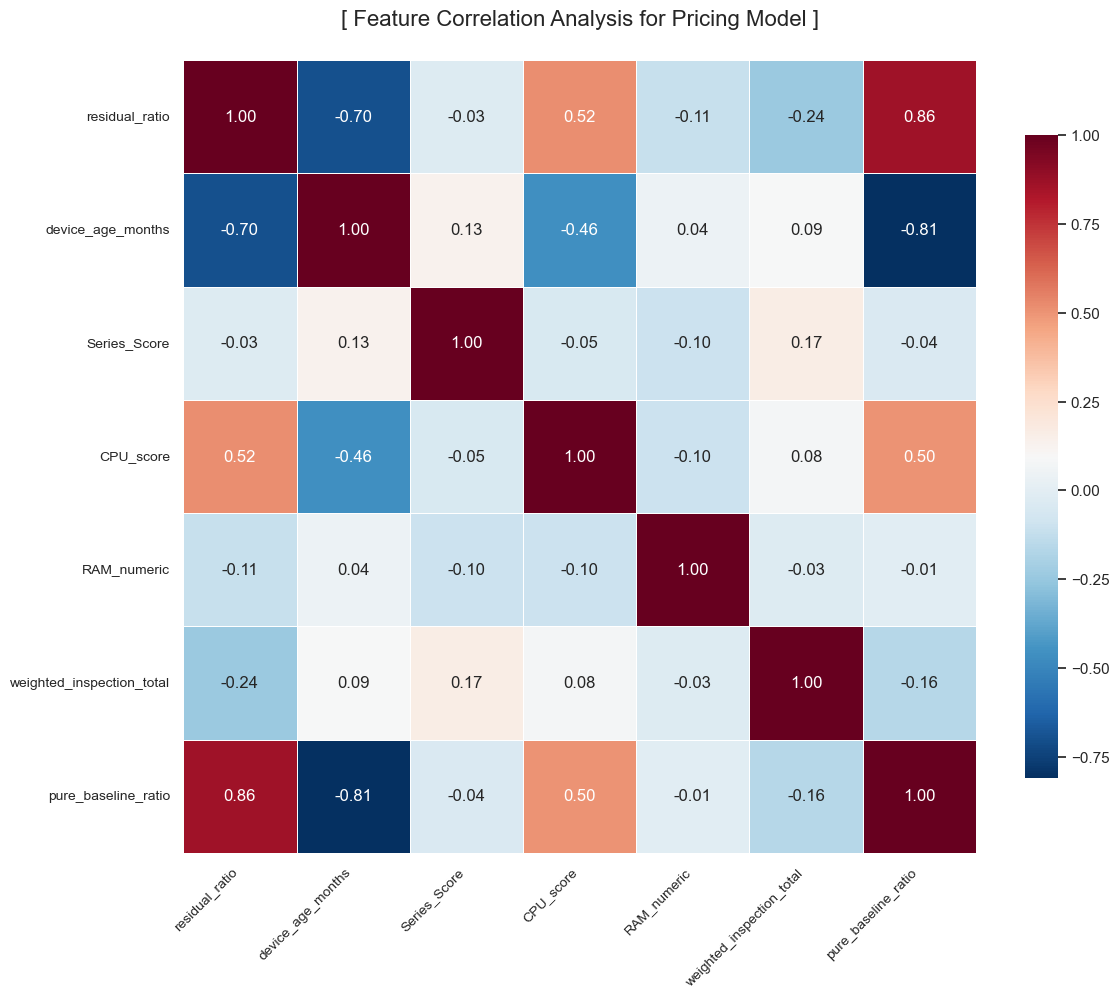

✅ 'feature_correlation_heatmap.png'로 저장되었습니다.


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화 데이터 준비 (이전과 동일)
focus_cols = [
    'residual_ratio', 'device_age_months', 'Series_Score', 
    'CPU_score', 'RAM_numeric', 'weighted_inspection_total', 'pure_baseline_ratio'
]
corr_matrix = df_final_v3[focus_cols].corr()

# 2. 그래프 크기 설정 (피처가 많다면 가로/세로 비율을 충분히 줍니다)
plt.figure(figsize=(12, 10))

# 3. 히트맵 그리기
sns.set(style="white")
ax = sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            linewidths=0.5, 
            square=True,
            cbar_kws={"shrink": .8}) # 컬러바 크기 조절

# 4. 축 레이블 폰트 및 각도 조절 (이름이 길면 45도 회전이 효과적입니다)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.yticks(rotation=0, fontsize=10)

plt.title("[ Feature Correlation Analysis for Pricing Model ]", fontsize=16, pad=25)

# [핵심] 5. 여백 자동 조정 (이름이 잘리는 현상을 방지합니다)
plt.tight_layout()

# 6. 고해상도 저장 (PPT용은 dpi=300 이상 추천)
# bbox_inches='tight'는 그래프 바깥으로 삐져나온 텍스트까지 포함해서 저장합니다.
plt.savefig('feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()
print("✅ 'feature_correlation_heatmap.png'로 저장되었습니다.")